# 01 — Initial EDA
**Project:** Presyong Bigas Predictor  
**Sprint:** 1, Week 4  
**Data:** `data/processed/ncr_rice_prices_clean.csv`  
**Coverage:** NCR retail rice prices — January 2018 to December 2025 (288 rows, 3 commodities)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Paths 
DATA_PATH = Path.cwd().parent / "data/processed/ncr_rice_prices_clean.csv"

# Style 
sns.set_theme(style="whitegrid", palette="muted")
COMMODITY_ORDER   = ["well_milled", "regular_milled", "special"]
COMMODITY_LABELS  = {"well_milled": "Well-Milled", "regular_milled": "Regular-Milled", "special": "Special"}
COMMODITY_COLORS  = {"well_milled": "#4C72B0", "regular_milled": "#DD8452", "special": "#55A868"}

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# Enforce commodity ordering for consistent plots
df["commodity"] = pd.Categorical(df["commodity"], categories=COMMODITY_ORDER, ordered=True)
df = df.sort_values(["commodity", "date"]).reset_index(drop=True)

print(f"Shape  : {df.shape}")
print(f"Dates  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Rows per commodity:\n{df['commodity'].value_counts().sort_index()}")
df.head()

Shape  : (288, 8)
Dates  : 2018-01-01 → 2025-12-01
Rows per commodity:
commodity
well_milled       96
regular_milled    96
special           96
Name: count, dtype: int64


,date,price_per_kg,commodity,region,source,price_type,gap_filled,is_outlier
0,2018-01-01,43.80,well_milled,NCR,PSA,retail,False,False
1,2018-02-01,43.94,well_milled,NCR,PSA,retail,False,False
2,2018-03-01,44.17,well_milled,NCR,PSA,retail,False,False
3,2018-04-01,44.19,well_milled,NCR,PSA,retail,False,False
4,2018-05-01,44.34,well_milled,NCR,PSA,retail,False,False


## 2. Missing-Value Heatmap

All 288 rows are expected to be complete (no nulls, no gaps).  
The heatmap visualises this — any white cell would indicate a missing value.

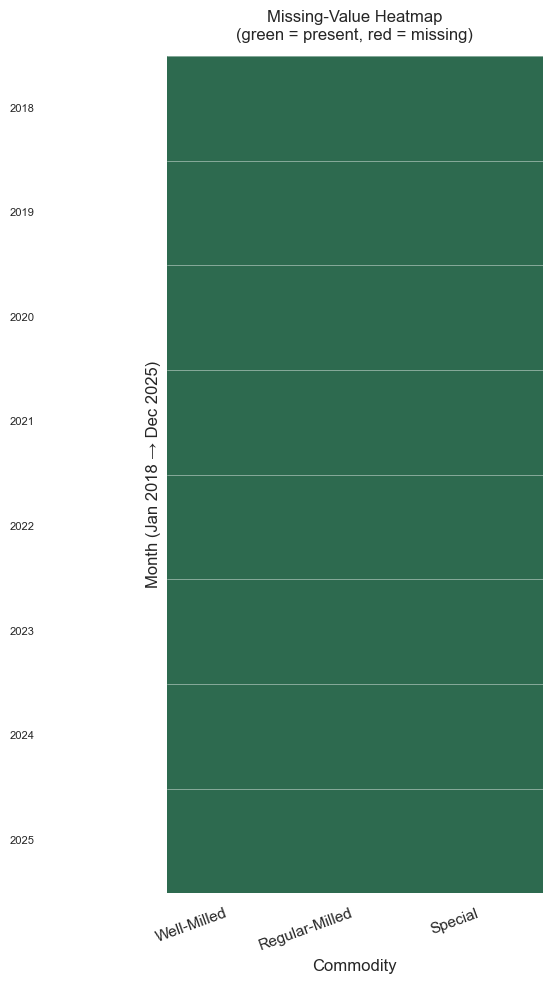


Null counts per commodity:
commodity
well_milled       0
regular_milled    0
special           0
dtype: int64


In [3]:
# Pivot: rows = months (date), columns = commodities 
pivot_prices = df.pivot(index="date", columns="commodity", values="price_per_kg")

# Build a boolean missing mask (True = missing)
missing_mask = pivot_prices.isnull()

fig, ax = plt.subplots(figsize=(6, 10))

sns.heatmap(
    missing_mask,
    cmap=["#2d6a4f", "#d62828"],   # green = present, red = missing
    cbar=False,
    linewidths=0,
    ax=ax,
    yticklabels=False,
)

ax.set_title("Missing-Value Heatmap\n(green = present, red = missing)", fontsize=12, pad=12)
ax.set_xlabel("Commodity")
ax.set_ylabel("Month (Jan 2018 → Dec 2025)")
ax.set_xticklabels([COMMODITY_LABELS[c] for c in COMMODITY_ORDER], rotation=20, ha="right")

# Add year annotations on the y-axis
n_months = len(pivot_prices)
for year_idx, year in enumerate(range(2018, 2026)):
    row = year_idx * 12
    ax.axhline(row, color="white", linewidth=0.5, alpha=0.6)
    ax.text(-0.35, row + 6, str(year), ha="right", va="center", fontsize=8, transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.savefig("figures/missing_value_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nNull counts per commodity:")
print(missing_mask.sum())

## 3. Descriptive Statistics

In [4]:
# Per-commodity stats
stats = (
    df.groupby("commodity")["price_per_kg"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        cv=lambda x: x.std() / x.mean() * 100,   # coefficient of variation (%)
    )
    .round(2)
    .rename(index=COMMODITY_LABELS)
)

stats.columns = ["n", "Mean (₱/kg)", "Median (₱/kg)", "Std Dev", "Min", "Max", "CV (%)"]
print("Descriptive Statistics — NCR Retail Rice Prices (Jan 2018 – Dec 2025)")
print("=" * 70)
stats

Descriptive Statistics — NCR Retail Rice Prices (Jan 2018 – Dec 2025)


,n,Mean (₱/kg),Median (₱/kg),Std Dev,Min,Max,CV (%)
commodity,,,,,,,
Well-Milled,96,45.23,43.18,3.83,40.95,53.24,8.46
Regular-Milled,96,39.80,38.97,2.75,35.80,46.18,6.91
Special,96,56.08,55.58,2.56,52.68,61.46,4.56


In [5]:
#  Year-by-year annual means (useful for Results & Discussion) 
df["year"] = df["date"].dt.year

annual = (
    df.groupby(["year", "commodity"])["price_per_kg"]
    .mean()
    .round(2)
    .unstack("commodity")
)
annual.columns = [COMMODITY_LABELS[c] for c in annual.columns]
print("\nAnnual Mean Retail Price (₱/kg)")
print("=" * 50)
annual


Annual Mean Retail Price (₱/kg)


,Well-Milled,Regular-Milled,Special
year,,,
2018,44.68,39.01,56.03
2019,41.99,37.44,56.01
2020,42.06,37.22,55.45
2021,42.80,38.28,54.76
2022,43.12,38.98,52.94
2023,45.64,41.04,54.79
2024,52.76,45.28,61.06
2025,48.79,41.17,57.58


## 4. Price Time Series — All Three Commodities

Annotated with key structural events:
- **2019-03** — Rice Tariffication Law (RA 11203) signed
- **2023-08** — Sharp price surge (El Niño + global supply pressure)
- **2025-01** — Executive Order 105 (revised rice tariff regime)

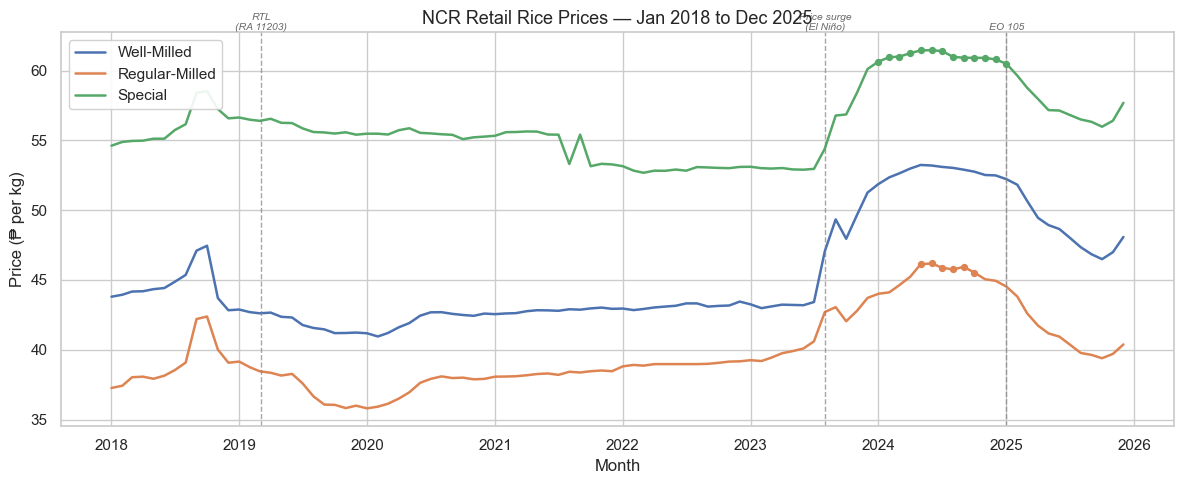

In [6]:
EVENTS = [
    ("2019-03-05", "RTL\n(RA 11203)"),
    ("2023-08-01", "Price surge\n(El Niño)"),
    ("2025-01-01", "EO 105"),
]

fig, ax = plt.subplots(figsize=(12, 5))

for commodity in COMMODITY_ORDER:
    subset = df[df["commodity"] == commodity]
    ax.plot(
        subset["date"],
        subset["price_per_kg"],
        label=COMMODITY_LABELS[commodity],
        color=COMMODITY_COLORS[commodity],
        linewidth=1.8,
    )
    # Mark outlier rows with a small dot
    outliers = subset[subset["is_outlier"]]
    ax.scatter(outliers["date"], outliers["price_per_kg"],
               color=COMMODITY_COLORS[commodity], s=18, zorder=5)

# Structural break annotations
for date_str, label in EVENTS:
    xval = pd.Timestamp(date_str)
    ax.axvline(xval, color="grey", linewidth=1, linestyle="--", alpha=0.7)
    ax.text(xval, ax.get_ylim()[1] if ax.get_ylim()[1] > 30 else 65,
            label, fontsize=7.5, color="dimgrey", ha="center",
            va="bottom", style="italic")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Month")
ax.set_ylabel("Price (₱ per kg)")
ax.set_title("NCR Retail Rice Prices — Jan 2018 to Dec 2025", fontsize=13)
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.savefig("figures/price_series_all_commodities.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Distribution — Box Plots by Year

Reveals within-year spread and shift in central tendency over time.

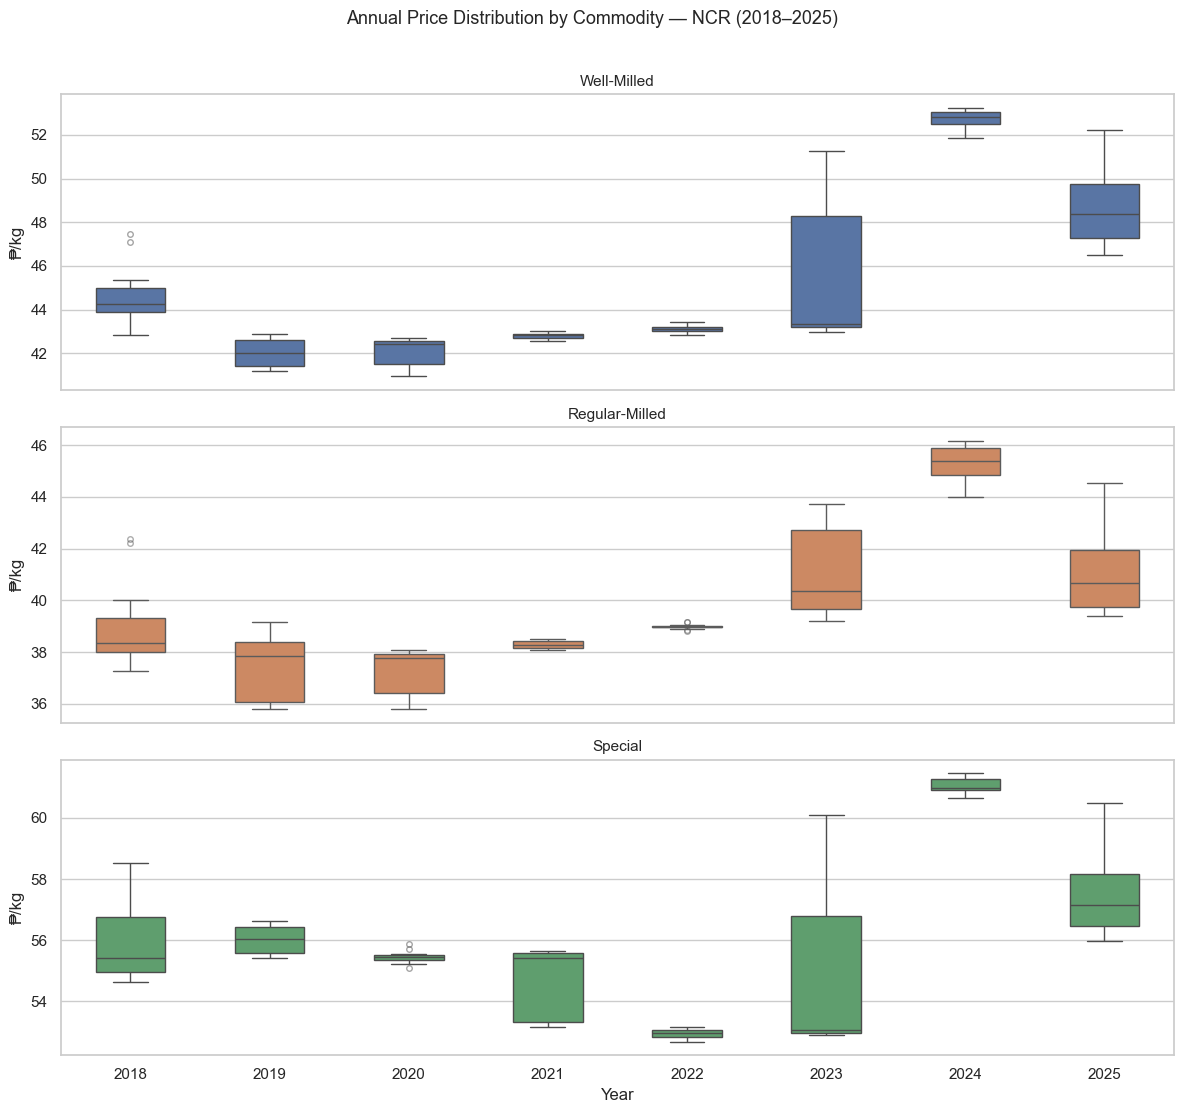

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for ax, commodity in zip(axes, COMMODITY_ORDER):
    subset = df[df["commodity"] == commodity]
    sns.boxplot(
        data=subset,
        x="year",
        y="price_per_kg",
        color=COMMODITY_COLORS[commodity],
        width=0.5,
        flierprops=dict(marker="o", markersize=4, alpha=0.5),
        ax=ax,
    )
    ax.set_title(COMMODITY_LABELS[commodity], fontsize=11)
    ax.set_ylabel("₱/kg")
    ax.set_xlabel("")

axes[-1].set_xlabel("Year")
fig.suptitle("Annual Price Distribution by Commodity — NCR (2018–2025)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/boxplot_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Outlier Summary

Flagged rows from `clean_psa.py` — IQR 1.5× fence, per commodity. All 19 flagged rows are real price movements (not data errors) and are kept in the training set.

In [8]:
outlier_summary = (
    df[df["is_outlier"]]
    .groupby("commodity")
    .agg(
        count=("price_per_kg", "count"),
        date_range=("date", lambda x: f"{x.min().strftime('%Y-%m')} → {x.max().strftime('%Y-%m')}"),
        price_range=("price_per_kg", lambda x: f"₱{x.min():.2f} – ₱{x.max():.2f}"),
    )
    .rename(index=COMMODITY_LABELS)
)
outlier_summary.columns = ["Flagged rows", "Date range", "Price range"]
print("Outlier Summary (is_outlier = True)")
print("=" * 55)
outlier_summary

Outlier Summary (is_outlier = True)


,Flagged rows,Date range,Price range
commodity,,,
Regular-Milled,6,2024-05 → 2024-10,₱45.53 – ₱46.18
Special,13,2024-01 → 2025-01,₱60.49 – ₱61.46


## 7. Key Observations

*(Update after reviewing output — template populated from data)*

**Well-Milled (primary series)**
- Prices were stable (≈ ₱41–44/kg) from 2018–2022, then surged sharply from mid-2023 onward, peaking around ₱53/kg in early 2024, before gradually declining through 2025.
- No outlier rows flagged — the IQR fence absorbed the surge as a legitimate level shift rather than a spike.
- Clear upward structural break post-mid-2023 aligns with the El Niño supply shock and global rice export restrictions.

**Regular-Milled**
- Declined from ≈ ₱39/kg (2018) to ≈ ₱36/kg (2019–2020) following the Rice Tariffication Law, then stabilised in the ₱38–39 range (2021–2023).
- Surged to ≈ ₱46/kg in mid-2024 (6 outlier rows: May–Oct 2024), before declining to ≈ ₱40/kg by Dec 2025.

**Special**
- Declined gradually from ≈ ₱56–58/kg (2018–2019) to ≈ ₱53/kg (2022–early 2023), then surged to ≈ ₱61/kg through all of 2024 (13 outlier rows).
- Partial recovery visible in 2025 (₱57–60/kg range).

**Cross-commodity pattern**
- All three commodities show the same 2023–2024 surge and 2025 partial recovery, suggesting a common supply-side driver (El Niño + global export restrictions) rather than commodity-specific factors.
- RTL (2019) appears to have had a more muted impact on special rice than on regular-milled.

**Sprint 2 implications**
- Stationarity testing (ADF) will need to account for the level shift around mid-2023.
- SARIMA seasonal order should be confirmed via ACF/PACF — seasonal pattern is subtle but may be present in Q3–Q4 spikes (harvest cycle).